# Heart Disease Prediction
# Phase 4 — Embedded Feature Selection
### UCI Cleveland Heart Disease Dataset
---
**Continues from:** `04_baseline_training.py`

**What is Embedded Feature Selection?**

Embedded methods select the most important features **during** the model training process itself.
Unlike Filter methods (which look at statistics only) or Wrapper methods (which train models repeatedly in loops),
Embedded methods let the model learn which features are useful **as part of fitting** — making them fast and accurate.

Think of it like this:
- 🔵 **Filter** = teacher marks features before class even starts (pure stats, no model)
- 🟡 **Wrapper** = trial and error — keep trying different feature subsets and check which model does best
- 🟢 **Embedded** = the model itself learns to ignore useless features while it trains

**Two Embedded Methods used here:**
1. **LASSO (L1 Regularization)** via Logistic Regression — shrinks weak feature weights to exactly 0
2. **Random Forest Feature Importance** — measures how much each feature reduces impurity across all trees

**Goal:** Find the best subset of features → retrain all 8 models → compare with Baseline

---
## Cell 1 — Install & Import Libraries

In [1]:
# ============================================================
# CELL 1 — Install & Import All Required Libraries
# ============================================================

!pip install xgboost --quiet

# --- Core libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- Embedded Feature Selection tools ---
from sklearn.linear_model import LogisticRegression       # For LASSO (L1)
from sklearn.ensemble import RandomForestClassifier       # For RF importance
from sklearn.feature_selection import SelectFromModel     # Extracts selected features

# --- The 8 Models (same as Baseline) ---
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from xgboost                 import XGBClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)
from sklearn.model_selection import cross_val_score

# --- Plot settings ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('=' * 55)
print('   All libraries imported successfully!')
print('=' * 55)

   All libraries imported successfully!


---
## Cell 2 — Load Preprocessed Data

> We load the exact same preprocessed data saved by `03_preprocessing.py`.
> This guarantees our feature selection experiment starts from the same point as the Baseline.

In [2]:
# ============================================================
# CELL 2 — Load Preprocessed Data from saved_data/
# ============================================================

LOAD_DIR = 'saved_data'

# Scaled versions → used for LASSO (Logistic Regression needs scaling)
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')

# Raw (unscaled) versions → used for Random Forest (trees don't need scaling)
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')

# Labels
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')

# Feature names (after One-Hot Encoding)
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# Baseline results (to compare against later)
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# Convert to proper pandas objects
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names) if not isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names) if not isinstance(X_test_scaled,  pd.DataFrame) else X_test_scaled
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names) if not isinstance(X_train_raw,    pd.DataFrame) else X_train_raw
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names) if not isinstance(X_test_raw,     pd.DataFrame) else X_test_raw
y_train        = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_test         = pd.Series(y_test)  if not isinstance(y_test,  pd.Series) else y_test

# Reset indices
for df in [X_train_scaled, X_test_scaled, X_train_raw, X_test_raw]:
    df.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print('Data loaded successfully!')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')
print(f'  X_train_raw    : {X_train_raw.shape}')
print(f'  X_test_raw     : {X_test_raw.shape}')
print(f'  y_train classes: {y_train.value_counts().to_dict()}')
print(f'  y_test  classes: {y_test.value_counts().to_dict()}')
print(f'  Total features : {len(feature_names)}')
print(f'  Feature names  : {feature_names}')

Data loaded successfully!
  X_train_scaled : (262, 22)
  X_test_scaled  : (61, 22)
  X_train_raw    : (262, 22)
  X_test_raw     : (61, 22)
  y_train classes: {1: 131, 0: 131}
  y_test  classes: {0: 33, 1: 28}
  Total features : 22
  Feature names  : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']


---
## Cell 3 — Method 1: LASSO (L1 Regularization)

### What is LASSO?

LASSO stands for **Least Absolute Shrinkage and Selection Operator**.

It works by adding a **penalty** to the Logistic Regression training process.
The penalty forces the model to shrink feature weights (coefficients) toward zero.
Weak features get their weight pushed all the way to **exactly 0** — meaning the model completely ignores them.

**The math behind it:**
- Normal Logistic Regression tries to minimize: `Loss`
- LASSO (L1) tries to minimize: `Loss + C × Σ|weights|`
- The `C` parameter controls the strength of the penalty:
  - Small `C` = strong penalty → many features get zeroed out
  - Large `C` = weak penalty → behaves like normal Logistic Regression

**Why is this "Embedded"?**
Because the feature selection happens automatically **inside** the model training.
We don't do any extra step — the model itself decides which features to keep by setting their weight to 0.

In [3]:
# ============================================================
# CELL 3 — LASSO Feature Selection (L1 Regularization)
# ============================================================

print('METHOD 1: LASSO (L1 Regularization) Feature Selection')
print('=' * 60)

# --- Step 1: Train Logistic Regression with L1 penalty ---
# penalty='l1'      → activates LASSO (forces some weights to exactly 0)
# C=0.1            → regularization strength (smaller = more features zeroed out)
# solver='liblinear'→ the only solver that supports L1 penalty in sklearn
# random_state=42   → reproducibility
lasso_model = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

lasso_model.fit(X_train_scaled, y_train)

# --- Step 2: Extract coefficients ---
# coef_ gives us the weight the model assigned to each feature
# Features with coefficient = 0 are completely ignored by the model
lasso_coefs = pd.Series(
    np.abs(lasso_model.coef_[0]),  # absolute value: direction doesn't matter, only magnitude
    index=feature_names
).sort_values(ascending=False)

print('Feature Coefficients (absolute values) from LASSO:')
print('-' * 50)
for feat, val in lasso_coefs.items():
    status = '✅ KEPT' if val > 0 else '❌ ZEROED OUT'
    print(f'  {status} | {feat:<20}: {val:.4f}')

# --- Step 3: Use SelectFromModel to extract kept features ---
# SelectFromModel automatically keeps features whose coefficient > threshold
# threshold=0.001 means: keep any feature with weight > 0.001
lasso_selector = SelectFromModel(lasso_model, prefit=True, threshold=0.001)

# Transform the data — keep only selected columns
X_train_lasso = lasso_selector.transform(X_train_scaled)
X_test_lasso  = lasso_selector.transform(X_test_scaled)

# Get the names of selected features
lasso_selected_features = [feature_names[i] for i in lasso_selector.get_support(indices=True)]

# Convert back to DataFrame
X_train_lasso = pd.DataFrame(X_train_lasso, columns=lasso_selected_features)
X_test_lasso  = pd.DataFrame(X_test_lasso,  columns=lasso_selected_features)

print(f'\nFeatures BEFORE LASSO: {len(feature_names)}')
print(f'Features AFTER  LASSO: {len(lasso_selected_features)}')
print(f'Features removed     : {len(feature_names) - len(lasso_selected_features)}')
print(f'Selected features    : {lasso_selected_features}')

METHOD 1: LASSO (L1 Regularization) Feature Selection
Feature Coefficients (absolute values) from LASSO:
--------------------------------------------------
  ✅ KEPT | thal_7              : 0.4320
  ✅ KEPT | cp_4.0              : 0.4047
  ✅ KEPT | ca_1                : 0.3564
  ✅ KEPT | oldpeak             : 0.3158
  ✅ KEPT | sex                 : 0.2622
  ✅ KEPT | thalach             : 0.2425
  ✅ KEPT | slope_2.0           : 0.2412
  ✅ KEPT | cp_3.0              : 0.1586
  ✅ KEPT | ca_2                : 0.1313
  ✅ KEPT | exang               : 0.1145
  ✅ KEPT | ca_3                : 0.0840
  ❌ ZEROED OUT | thal_4              : 0.0000
  ❌ ZEROED OUT | thal_6              : 0.0000
  ❌ ZEROED OUT | thal_5              : 0.0000
  ❌ ZEROED OUT | age                 : 0.0000
  ❌ ZEROED OUT | slope_3.0           : 0.0000
  ❌ ZEROED OUT | restecg_2.0         : 0.0000
  ❌ ZEROED OUT | cp_2.0              : 0.0000
  ❌ ZEROED OUT | fbs                 : 0.0000
  ❌ ZEROED OUT | chol               

---
## Cell 4 — Visualize LASSO Coefficients

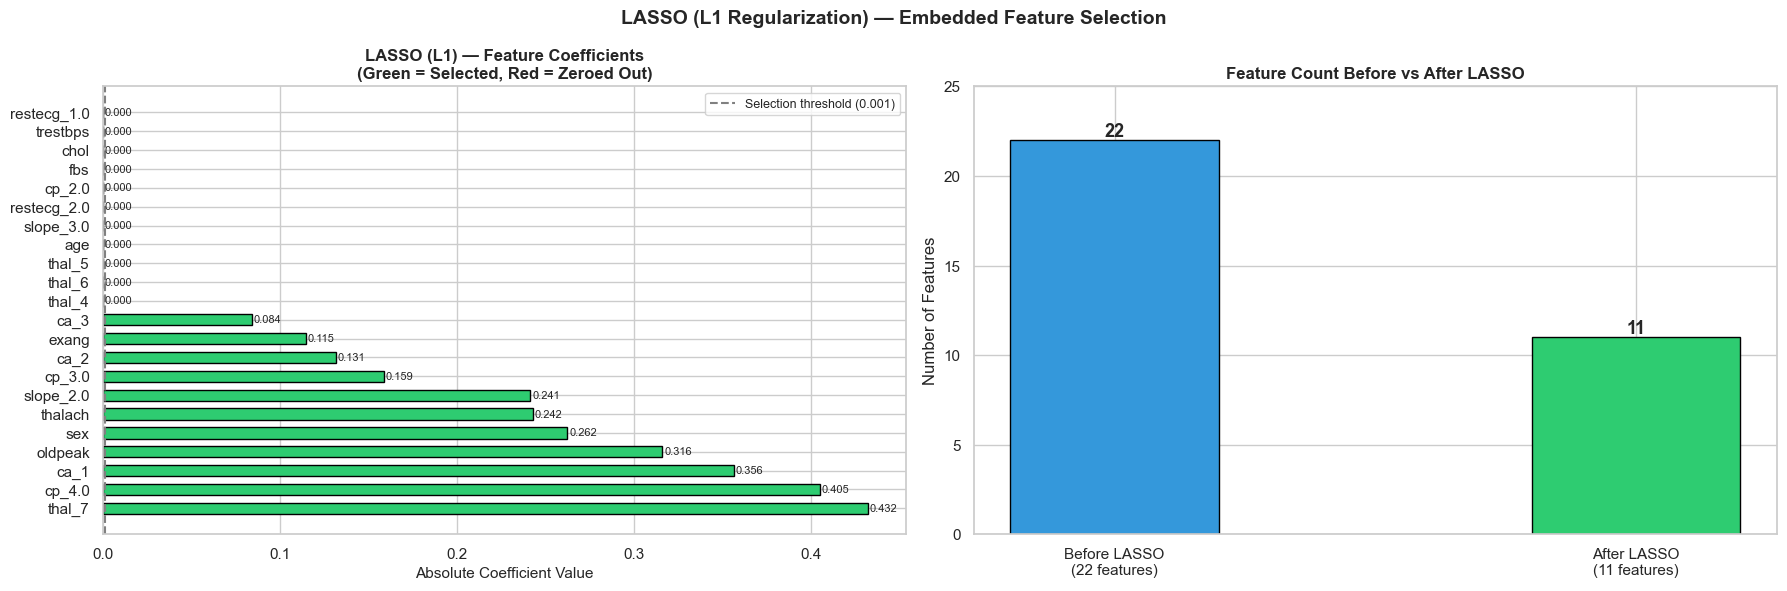

   LASSO visualization saved!


In [4]:
# ============================================================
# CELL 4 — Visualize LASSO Feature Coefficients
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: All coefficients (sorted by magnitude) ---
colors_lasso = ['#2ecc71' if v > 0.001 else '#e74c3c' for v in lasso_coefs.values]

bars = axes[0].barh(lasso_coefs.index, lasso_coefs.values,
                    color=colors_lasso, edgecolor='black', height=0.6)
axes[0].axvline(0.001, color='gray', linestyle='--', linewidth=1.5,
                label='Selection threshold (0.001)')
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=11)
axes[0].set_title('LASSO (L1) — Feature Coefficients\n(Green = Selected, Red = Zeroed Out)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Add value labels
for bar, val in zip(bars, lasso_coefs.values):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

# --- Plot 2: Before vs After feature count ---
counts = [len(feature_names), len(lasso_selected_features)]
labels = [f'Before LASSO\n({len(feature_names)} features)', 
          f'After LASSO\n({len(lasso_selected_features)} features)']
bar_colors = ['#3498db', '#2ecc71']

b = axes[1].bar(labels, counts, color=bar_colors, edgecolor='black', width=0.4)
for bar, val in zip(b, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2, str(val),
                ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Count Before vs After LASSO',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, len(feature_names) + 3)

plt.suptitle('LASSO (L1 Regularization) — Embedded Feature Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('embedded_lasso_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('   LASSO visualization saved!')

---
## Cell 5 — Method 2: Random Forest Feature Importance

### What is Random Forest Feature Importance?

Random Forest builds many Decision Trees. Each tree splits data using features.
When a feature is used to split, it reduces **impurity** (makes the groups purer — more sick in one side, more healthy in the other).

**Feature Importance = how much each feature reduced impurity, averaged across all trees.**

Features that appear in many trees and cause large impurity reduction → High importance → KEEP
Features that rarely get used or cause tiny reductions → Low importance → REMOVE

**Why is this "Embedded"?**
Because the importance scores are computed **during** the Random Forest training.
The model doesn't run twice — the importance is a natural byproduct of learning the trees.

**Difference from LASSO:**
- LASSO works best for **linear** relationships between features and target
- Random Forest captures **non-linear** relationships too
- Together they give us a more complete picture

In [5]:
# ============================================================
# CELL 5 — Random Forest Feature Importance
# ============================================================

print('METHOD 2: Random Forest Feature Importance')
print('=' * 60)

# --- Step 1: Train a Random Forest ---
# n_estimators=200 → 200 trees (more trees = more reliable importance scores)
# random_state=42  → reproducibility
rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# We use raw (unscaled) data — Random Forest doesn't need scaling
rf_selector.fit(X_train_raw, y_train)

# --- Step 2: Extract importance scores ---
# feature_importances_ gives a score for each feature (they all sum to 1.0)
rf_importances = pd.Series(
    rf_selector.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('Feature Importance Scores from Random Forest:')
print('-' * 55)

# Threshold: keep features with importance > mean importance
# This is a common strategy: only keep features that are above average
mean_importance = rf_importances.mean()
print(f'  Mean importance threshold: {mean_importance:.4f}')
print()

for feat, val in rf_importances.items():
    status = '✅ KEPT' if val >= mean_importance else '❌ DROPPED'
    bar    = '█' * int(val * 200)  # visual bar
    print(f'  {status} | {feat:<20}: {val:.4f}  {bar}')

# --- Step 3: Select features above mean importance ---
# SelectFromModel with threshold='mean' automatically keeps features > mean importance
rf_feature_selector = SelectFromModel(rf_selector, prefit=True, threshold='mean')

X_train_rf = rf_feature_selector.transform(X_train_raw)
X_test_rf  = rf_feature_selector.transform(X_test_raw)

rf_selected_features = [feature_names[i] for i in rf_feature_selector.get_support(indices=True)]

X_train_rf = pd.DataFrame(X_train_rf, columns=rf_selected_features)
X_test_rf  = pd.DataFrame(X_test_rf,  columns=rf_selected_features)

print(f'\nFeatures BEFORE RF Selection: {len(feature_names)}')
print(f'Features AFTER  RF Selection: {len(rf_selected_features)}')
print(f'Features removed            : {len(feature_names) - len(rf_selected_features)}')
print(f'Selected features           : {rf_selected_features}')

METHOD 2: Random Forest Feature Importance
Feature Importance Scores from Random Forest:
-------------------------------------------------------
  Mean importance threshold: 0.0455

  ✅ KEPT | thalach             : 0.1388  ███████████████████████████
  ✅ KEPT | oldpeak             : 0.1126  ██████████████████████
  ✅ KEPT | age                 : 0.1022  ████████████████████
  ✅ KEPT | chol                : 0.0929  ██████████████████
  ✅ KEPT | trestbps            : 0.0894  █████████████████
  ✅ KEPT | thal_7              : 0.0833  ████████████████
  ✅ KEPT | cp_4.0              : 0.0758  ███████████████
  ✅ KEPT | exang               : 0.0486  █████████
  ❌ DROPPED | slope_2.0           : 0.0452  █████████
  ❌ DROPPED | sex                 : 0.0424  ████████
  ❌ DROPPED | ca_1                : 0.0381  ███████
  ❌ DROPPED | cp_3.0              : 0.0336  ██████
  ❌ DROPPED | cp_2.0              : 0.0234  ████
  ❌ DROPPED | restecg_2.0         : 0.0227  ████
  ❌ DROPPED | ca_2            

---
## Cell 6 — Visualize Random Forest Importance

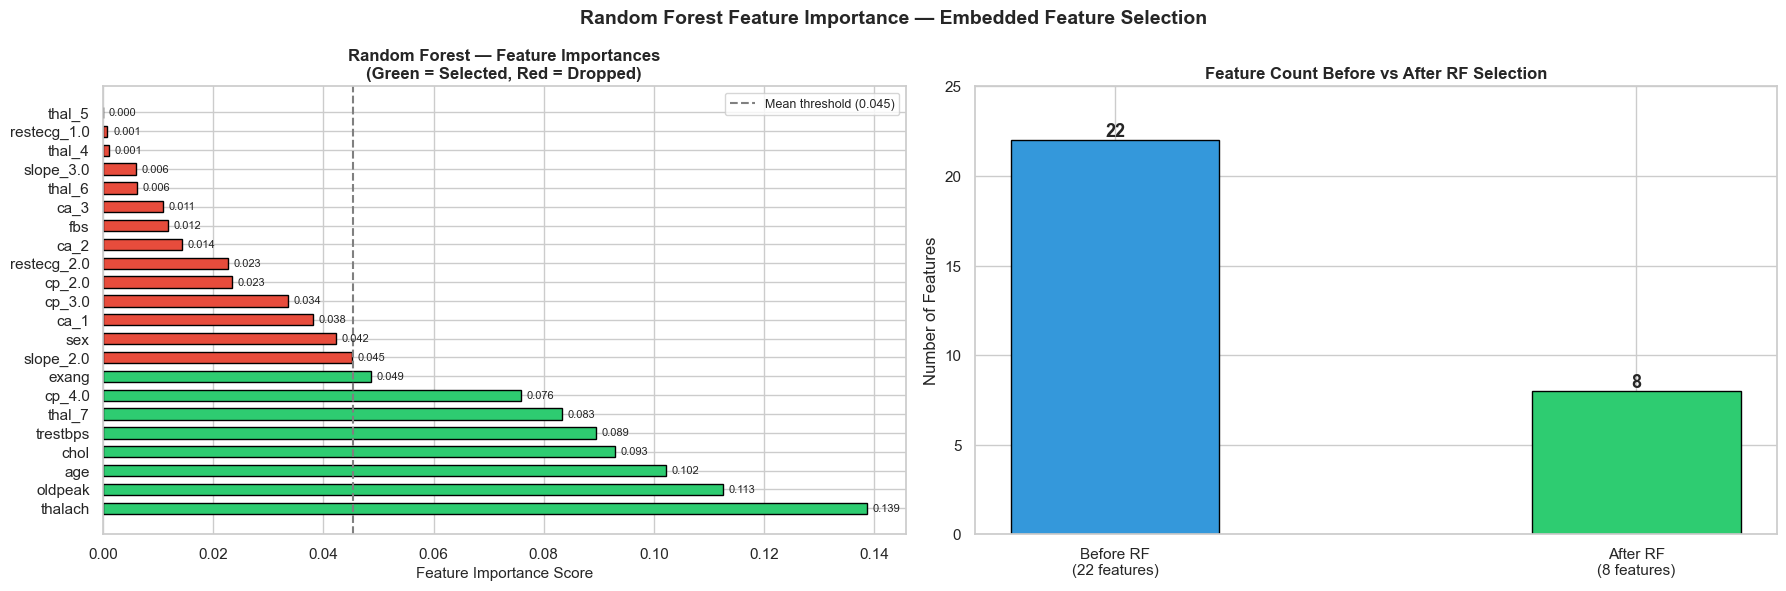

   RF importance visualization saved!


In [6]:
# ============================================================
# CELL 6 — Visualize Random Forest Feature Importances
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Importance bar chart ---
colors_rf = ['#2ecc71' if v >= mean_importance else '#e74c3c' 
             for v in rf_importances.values]

bars = axes[0].barh(rf_importances.index, rf_importances.values,
                    color=colors_rf, edgecolor='black', height=0.6)
axes[0].axvline(mean_importance, color='gray', linestyle='--', linewidth=1.5,
                label=f'Mean threshold ({mean_importance:.3f})')
axes[0].set_xlabel('Feature Importance Score', fontsize=11)
axes[0].set_title('Random Forest — Feature Importances\n(Green = Selected, Red = Dropped)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

for bar, val in zip(bars, rf_importances.values):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

# --- Plot 2: Before vs After feature count ---
counts = [len(feature_names), len(rf_selected_features)]
labels = [f'Before RF\n({len(feature_names)} features)',
          f'After RF\n({len(rf_selected_features)} features)']

b = axes[1].bar(labels, counts, color=['#3498db', '#2ecc71'], edgecolor='black', width=0.4)
for bar, val in zip(b, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2, str(val),
                ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Count Before vs After RF Selection',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, len(feature_names) + 3)

plt.suptitle('Random Forest Feature Importance — Embedded Feature Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('embedded_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('   RF importance visualization saved!')

---
## Cell 7 — Compare Selected Features: LASSO vs Random Forest

> Which features did both methods agree on? Features selected by **both** methods are the strongest candidates — two different algorithms both decided they matter.

In [7]:
# ============================================================
# CELL 7 — Compare LASSO vs RF Selected Features
# ============================================================

lasso_set = set(lasso_selected_features)
rf_set    = set(rf_selected_features)

# Features selected by BOTH methods → most confident selection
both_selected    = lasso_set & rf_set
# Features selected by LASSO only
lasso_only       = lasso_set - rf_set
# Features selected by RF only
rf_only          = rf_set - lasso_set
# Features dropped by BOTH → clearly useless
neither_selected = set(feature_names) - (lasso_set | rf_set)

print('FEATURE SELECTION COMPARISON: LASSO vs Random Forest')
print('=' * 60)
print(f'  Total features           : {len(feature_names)}')
print(f'  LASSO selected           : {len(lasso_set)}  → {sorted(lasso_set)}')
print(f'  RF selected              : {len(rf_set)}  → {sorted(rf_set)}')
print()
print(f'  ✅ Selected by BOTH      : {len(both_selected)} → {sorted(both_selected)}')
print(f'  🔵 LASSO only            : {len(lasso_only)}  → {sorted(lasso_only)}')
print(f'  🟡 RF only               : {len(rf_only)}  → {sorted(rf_only)}')
print(f'  ❌ Dropped by BOTH       : {len(neither_selected)} → {sorted(neither_selected)}')

# --- Venn-style summary table ---
summary_data = []
for feat in feature_names:
    in_lasso = feat in lasso_set
    in_rf    = feat in rf_set
    if in_lasso and in_rf:
        verdict = '✅ Both'
    elif in_lasso:
        verdict = '🔵 LASSO only'
    elif in_rf:
        verdict = '🟡 RF only'
    else:
        verdict = '❌ Neither'
    summary_data.append({
        'Feature': feat,
        'LASSO': '✅' if in_lasso else '❌',
        'RF':    '✅' if in_rf    else '❌',
        'Verdict': verdict
    })

summary_df = pd.DataFrame(summary_data)
print()
print('Full Feature Selection Summary:')
display(summary_df)

# --- Final selected features: union of both methods ---
# We use the UNION (features selected by at least one method)
# This is a liberal approach — keeps more features, reduces risk of losing important ones
final_selected_features = sorted(lasso_set | rf_set)
print(f'\n  Final selected features (union): {len(final_selected_features)}')
print(f'  → {final_selected_features}')

FEATURE SELECTION COMPARISON: LASSO vs Random Forest
  Total features           : 22
  LASSO selected           : 11  → ['ca_1', 'ca_2', 'ca_3', 'cp_3.0', 'cp_4.0', 'exang', 'oldpeak', 'sex', 'slope_2.0', 'thal_7', 'thalach']
  RF selected              : 8  → ['age', 'chol', 'cp_4.0', 'exang', 'oldpeak', 'thal_7', 'thalach', 'trestbps']

  ✅ Selected by BOTH      : 5 → ['cp_4.0', 'exang', 'oldpeak', 'thal_7', 'thalach']
  🔵 LASSO only            : 6  → ['ca_1', 'ca_2', 'ca_3', 'cp_3.0', 'sex', 'slope_2.0']
  🟡 RF only               : 3  → ['age', 'chol', 'trestbps']
  ❌ Dropped by BOTH       : 8 → ['cp_2.0', 'fbs', 'restecg_1.0', 'restecg_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6']

Full Feature Selection Summary:


,Feature,LASSO,RF,Verdict
0,age,❌,✅,🟡 RF only
1,sex,✅,❌,🔵 LASSO only
2,trestbps,❌,✅,🟡 RF only
3,chol,❌,✅,🟡 RF only
4,fbs,❌,❌,❌ Neither
5,thalach,✅,✅,✅ Both
6,exang,✅,✅,✅ Both
7,oldpeak,✅,✅,✅ Both
8,cp_2.0,❌,❌,❌ Neither
9,cp_3.0,✅,❌,🔵 LASSO only



  Final selected features (union): 14
  → ['age', 'ca_1', 'ca_2', 'ca_3', 'chol', 'cp_3.0', 'cp_4.0', 'exang', 'oldpeak', 'sex', 'slope_2.0', 'thal_7', 'thalach', 'trestbps']


---
## Cell 8 — Prepare Final Feature Subsets for Model Training

> We will train all 8 models on **3 different feature subsets** and compare:
> 1. LASSO-selected features
> 2. RF-selected features  
> 3. Union of both (final combined selection)

In [8]:
# ============================================================
# CELL 8 — Prepare Final Feature Subsets
# ============================================================

# --- Subset 1: LASSO selected (scaled, for scale-sensitive models) ---
# Already prepared: X_train_lasso, X_test_lasso

# --- Subset 2: RF selected (raw, for tree-based models) ---
# Already prepared: X_train_rf, X_test_rf

# --- Subset 3: Union of both (scaled, for all models) ---
# We use the scaled version so ALL 8 models can use this subset
X_train_union = X_train_scaled[final_selected_features].reset_index(drop=True)
X_test_union  = X_test_scaled[final_selected_features].reset_index(drop=True)

print('Feature Subsets Ready for Training:')
print('=' * 55)
print(f'  Subset 1 — LASSO    : {X_train_lasso.shape[1]} features | {X_train_lasso.shape[0]} train samples')
print(f'    Features: {list(X_train_lasso.columns)}')
print()
print(f'  Subset 2 — RF       : {X_train_rf.shape[1]} features | {X_train_rf.shape[0]} train samples')
print(f'    Features: {list(X_train_rf.columns)}')
print()
print(f'  Subset 3 — Union    : {X_train_union.shape[1]} features | {X_train_union.shape[0]} train samples')
print(f'    Features: {list(X_train_union.columns)}')
print()
print(f'  Baseline (original) : {len(feature_names)} features')

Feature Subsets Ready for Training:
  Subset 1 — LASSO    : 11 features | 262 train samples
    Features: ['sex', 'thalach', 'exang', 'oldpeak', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7', 'ca_1', 'ca_2', 'ca_3']

  Subset 2 — RF       : 8 features | 262 train samples
    Features: ['age', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'cp_4.0', 'thal_7']

  Subset 3 — Union    : 14 features | 262 train samples
    Features: ['age', 'ca_1', 'ca_2', 'ca_3', 'chol', 'cp_3.0', 'cp_4.0', 'exang', 'oldpeak', 'sex', 'slope_2.0', 'thal_7', 'thalach', 'trestbps']

  Baseline (original) : 22 features


---
## Cell 9 — Define All 8 Models (Same as Baseline)

> We use the exact same model definitions as the Baseline. The only difference is the features we feed into them.

In [9]:
# ============================================================
# CELL 9 — Define All 8 Classifiers (Identical to Baseline)
# ============================================================

def get_models():
    """Returns a fresh dictionary of all 8 untrained models.
    We use a function so we can get fresh (untrained) models for each experiment."""
    return {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=5),
        'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
        'SVM':                 SVC(random_state=42, kernel='rbf', probability=True),
        'KNN':                 KNeighborsClassifier(n_neighbors=5),
        'XGBoost':             XGBClassifier(random_state=42, n_estimators=100,
                                             eval_metric='logloss', use_label_encoder=False),
        'Naive Bayes':         GaussianNB(),
        'Neural Network':      MLPClassifier(random_state=42, hidden_layer_sizes=(64, 32),
                                             activation='relu', max_iter=500)
    }

print(f'   8 model definitions ready!')
for i, name in enumerate(get_models().keys(), 1):
    print(f'  {i}. {name}')

   8 model definitions ready!
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. SVM
  5. KNN
  6. XGBoost
  7. Naive Bayes
  8. Neural Network


---
## Cell 10 — Train & Evaluate All Models on All Feature Subsets

> This is the core experiment. We train all 8 models × 3 subsets = 24 experiments.
> Results are stored so we can compare everything at the end.

In [10]:
# ============================================================
# CELL 10 — Train All 8 Models × 3 Feature Subsets
# ============================================================

def train_and_evaluate(X_tr, X_te, y_tr, y_te, subset_name):
    """
    Train all 8 models on a given feature subset and return results.
    
    Parameters:
        X_tr        : Training features
        X_te        : Test features
        y_tr        : Training labels
        y_te        : Test labels
        subset_name : Name label for this experiment (e.g. 'LASSO')
    
    Returns:
        results dict : {model_name: {metric: value, ...}}
    """
    models   = get_models()
    results  = {}

    print(f'\nTraining on: {subset_name} ({X_tr.shape[1]} features)')
    print('-' * 55)

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec  = recall_score(y_te, y_pred, zero_division=0)
        f1   = f1_score(y_te, y_pred, zero_division=0)
        auc  = roc_auc_score(y_te, y_prob)
        cv   = cross_val_score(model, X_tr, y_tr, cv=10, scoring='accuracy').mean()

        results[name] = {
            'Accuracy':  round(acc  * 100, 2),
            'Precision': round(prec * 100, 2),
            'Recall':    round(rec  * 100, 2),
            'F1-Score':  round(f1   * 100, 2),
            'ROC-AUC':   round(auc  * 100, 2),
            'CV Score':  round(cv   * 100, 2)
        }
        print(f'  {name:<22} | Acc={acc*100:.1f}%  Recall={rec*100:.1f}%  AUC={auc*100:.1f}%')

    return results


# --- Run all 3 experiments ---
print('=' * 55)
print('TRAINING ALL MODELS ON ALL FEATURE SUBSETS')
print('=' * 55)

results_lasso = train_and_evaluate(
    X_train_lasso, X_test_lasso, y_train, y_test, 'LASSO Selected'
)

results_rf = train_and_evaluate(
    X_train_rf, X_test_rf, y_train, y_test, 'RF Selected'
)

results_union = train_and_evaluate(
    X_train_union, X_test_union, y_train, y_test, 'Union (LASSO + RF)'
)

print('\n   All experiments complete!')

TRAINING ALL MODELS ON ALL FEATURE SUBSETS

Training on: LASSO Selected (11 features)
-------------------------------------------------------
  Logistic Regression    | Acc=86.9%  Recall=92.9%  AUC=94.8%
  Decision Tree          | Acc=75.4%  Recall=75.0%  AUC=79.5%
  Random Forest          | Acc=88.5%  Recall=96.4%  AUC=93.4%
  SVM                    | Acc=88.5%  Recall=92.9%  AUC=94.7%
  KNN                    | Acc=83.6%  Recall=89.3%  AUC=93.2%
  XGBoost                | Acc=83.6%  Recall=89.3%  AUC=92.7%
  Naive Bayes            | Acc=90.2%  Recall=92.9%  AUC=92.4%
  Neural Network         | Acc=83.6%  Recall=89.3%  AUC=90.4%

Training on: RF Selected (8 features)
-------------------------------------------------------
  Logistic Regression    | Acc=86.9%  Recall=89.3%  AUC=96.2%
  Decision Tree          | Acc=60.7%  Recall=50.0%  AUC=65.5%
  Random Forest          | Acc=90.2%  Recall=96.4%  AUC=93.7%
  SVM                    | Acc=73.8%  Recall=67.9%  AUC=78.4%
  KNN              

---
## Cell 11 — Results Tables for Each Feature Subset

In [11]:
# ============================================================
# CELL 11 — Display Results Tables for Each Subset
# ============================================================

def show_results_table(results_dict, title):
    """Convert results dict to styled DataFrame and display it."""
    df_res = pd.DataFrame(results_dict).T
    df_res.index.name = 'Model'
    df_res = df_res.sort_values('F1-Score', ascending=False)

    print(f'\n{"=" * 65}')
    print(f'  {title}')
    print(f'  Sorted by F1-Score | All values in %')
    print(f'{"=" * 65}')
    display(df_res.style
        .format('{:.2f}%')
        .background_gradient(cmap='YlGn', axis=0)
        .highlight_max(color='#2ecc71', axis=0)
        .highlight_min(color='#ffcccc', axis=0)
    )
    return df_res

df_lasso = show_results_table(results_lasso, f'LASSO Selected Features ({len(lasso_selected_features)} features)')
df_rf    = show_results_table(results_rf,    f'RF Selected Features ({len(rf_selected_features)} features)')
df_union = show_results_table(results_union, f'Union Selected Features ({len(final_selected_features)} features)')


  LASSO Selected Features (11 features)
  Sorted by F1-Score | All values in %


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Model,,,,,,
Naive Bayes,90.16%,86.67%,92.86%,89.66%,92.42%,76.62%
Random Forest,88.52%,81.82%,96.43%,88.52%,93.40%,80.07%
SVM,88.52%,83.87%,92.86%,88.14%,94.70%,79.69%
Logistic Regression,86.89%,81.25%,92.86%,86.67%,94.81%,81.23%
KNN,83.61%,78.12%,89.29%,83.33%,93.18%,76.67%
XGBoost,83.61%,78.12%,89.29%,83.33%,92.75%,75.91%
Neural Network,83.61%,78.12%,89.29%,83.33%,90.37%,79.73%
Decision Tree,75.41%,72.41%,75.00%,73.68%,79.49%,72.05%



  RF Selected Features (8 features)
  Sorted by F1-Score | All values in %


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Model,,,,,,
Random Forest,90.16%,84.38%,96.43%,90.00%,93.67%,74.33%
Naive Bayes,88.52%,80.00%,100.00%,88.89%,97.29%,76.65%
Logistic Regression,86.89%,83.33%,89.29%,86.21%,96.21%,75.10%
Neural Network,86.89%,88.46%,82.14%,85.19%,94.70%,69.09%
XGBoost,83.61%,80.00%,85.71%,82.76%,90.04%,71.71%
SVM,73.77%,73.08%,67.86%,70.37%,78.41%,68.30%
KNN,72.13%,70.37%,67.86%,69.09%,77.16%,64.13%
Decision Tree,60.66%,58.33%,50.00%,53.85%,65.48%,71.31%



  Union Selected Features (14 features)
  Sorted by F1-Score | All values in %


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Model,,,,,,
SVM,90.16%,82.35%,100.00%,90.32%,94.48%,80.47%
Logistic Regression,90.16%,84.38%,96.43%,90.00%,95.24%,81.98%
KNN,90.16%,84.38%,96.43%,90.00%,95.51%,78.18%
XGBoost,90.16%,84.38%,96.43%,90.00%,92.10%,79.76%
Naive Bayes,88.52%,81.82%,96.43%,88.52%,92.32%,76.27%
Random Forest,88.52%,83.87%,92.86%,88.14%,94.97%,79.33%
Neural Network,85.25%,82.76%,85.71%,84.21%,94.37%,77.05%
Decision Tree,60.66%,57.69%,53.57%,55.56%,66.23%,71.31%


---
## Cell 12 — Compare Embedded vs Baseline: Head-to-Head

> The most important comparison: did feature selection actually improve things?
> We compare the **best result from each subset** against the **Baseline** for each model.

In [12]:
# ============================================================
# CELL 12 — Embedded vs Baseline Comparison
# ============================================================

model_names = list(get_models().keys())
metric = 'F1-Score'   # Primary metric for comparison

print(f'HEAD-TO-HEAD COMPARISON — {metric}')
print('=' * 75)
print(f'  {"Model":<22} | {"Baseline":>9} | {"LASSO":>9} | {"RF":>9} | {"Union":>9} | Best')
print('-' * 75)

comparison_rows = []

for name in model_names:
    base_val  = baseline_results[name][metric]
    lasso_val = results_lasso[name][metric]
    rf_val    = results_rf[name][metric]
    union_val = results_union[name][metric]

    best_val  = max(base_val, lasso_val, rf_val, union_val)
    best_name = ['Baseline', 'LASSO', 'RF', 'Union'][
        [base_val, lasso_val, rf_val, union_val].index(best_val)
    ]

    # Arrow shows improvement or drop vs baseline
    best_embedded = max(lasso_val, rf_val, union_val)
    delta = best_embedded - base_val
    arrow = f'↑ +{delta:.1f}%' if delta > 0 else (f'↓ {delta:.1f}%' if delta < 0 else '→ same')

    print(f'  {name:<22} | {base_val:>8.2f}% | {lasso_val:>8.2f}% | {rf_val:>8.2f}% | {union_val:>8.2f}% | {best_name} {arrow}')

    comparison_rows.append({
        'Model': name,
        'Baseline': base_val,
        'LASSO': lasso_val,
        'RF': rf_val,
        'Union': union_val,
        'Best Subset': best_name,
        'Change vs Baseline': round(delta, 2)
    })

comparison_df = pd.DataFrame(comparison_rows)
print()
print('Summary:')
improved = (comparison_df['Change vs Baseline'] > 0).sum()
declined = (comparison_df['Change vs Baseline'] < 0).sum()
same     = (comparison_df['Change vs Baseline'] == 0).sum()
print(f'  Models improved by Embedded FS : {improved}')
print(f'  Models declined                : {declined}')
print(f'  Models unchanged               : {same}')

HEAD-TO-HEAD COMPARISON — F1-Score
  Model                  |  Baseline |     LASSO |        RF |     Union | Best
---------------------------------------------------------------------------
  Logistic Regression    |    84.21% |    86.67% |    86.21% |    90.00% | Union ↑ +5.8%
  Decision Tree          |    65.45% |    73.68% |    53.85% |    55.56% | LASSO ↑ +8.2%
  Random Forest          |    90.00% |    88.52% |    90.00% |    88.14% | Baseline → same
  SVM                    |    90.32% |    88.14% |    70.37% |    90.32% | Baseline → same
  KNN                    |    85.71% |    83.33% |    69.09% |    90.00% | Union ↑ +4.3%
  XGBoost                |    86.67% |    83.33% |    82.76% |    90.00% | Union ↑ +3.3%
  Naive Bayes            |    82.14% |    89.66% |    88.89% |    88.52% | LASSO ↑ +7.5%
  Neural Network         |    78.57% |    83.33% |    85.19% |    84.21% | RF ↑ +6.6%

Summary:
  Models improved by Embedded FS : 6
  Models declined                : 0
  Models unc

---
## Cell 13 — Visualization: Baseline vs Embedded (All Models)

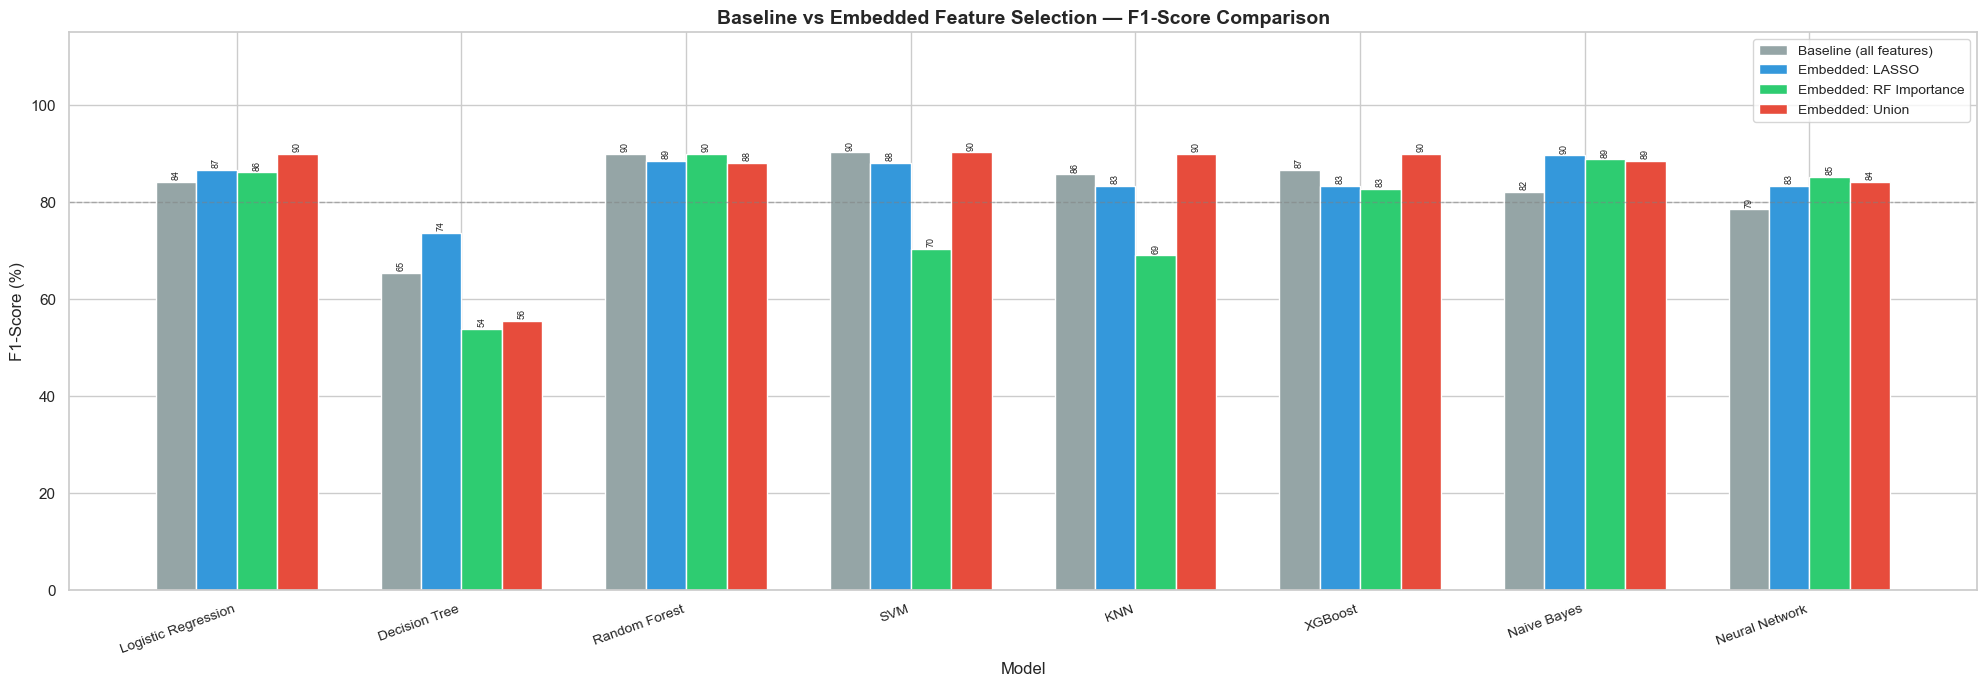

   Comparison bar chart saved!


In [13]:
# ============================================================
# CELL 13 — Grouped Bar Chart: Baseline vs All Embedded Subsets
# ============================================================

metric = 'F1-Score'

x         = np.arange(len(model_names))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(20, 7))

# Each group of 4 bars = one model (Baseline, LASSO, RF, Union)
b1 = ax.bar(x - 1.5*bar_width, [baseline_results[n][metric] for n in model_names],
            bar_width, label='Baseline (all features)', color='#95a5a6', edgecolor='white')
b2 = ax.bar(x - 0.5*bar_width, [results_lasso[n][metric] for n in model_names],
            bar_width, label='Embedded: LASSO', color='#3498db', edgecolor='white')
b3 = ax.bar(x + 0.5*bar_width, [results_rf[n][metric] for n in model_names],
            bar_width, label='Embedded: RF Importance', color='#2ecc71', edgecolor='white')
b4 = ax.bar(x + 1.5*bar_width, [results_union[n][metric] for n in model_names],
            bar_width, label='Embedded: Union', color='#e74c3c', edgecolor='white')

# Value labels on top of each bar
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.0f}',
                ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel(f'{metric} (%)', fontsize=12)
ax.set_title(f'Baseline vs Embedded Feature Selection — {metric} Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 115)
ax.axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('embedded_vs_baseline_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Comparison bar chart saved!')

---
## Cell 14 — Performance Heatmaps: All Subsets Side by Side

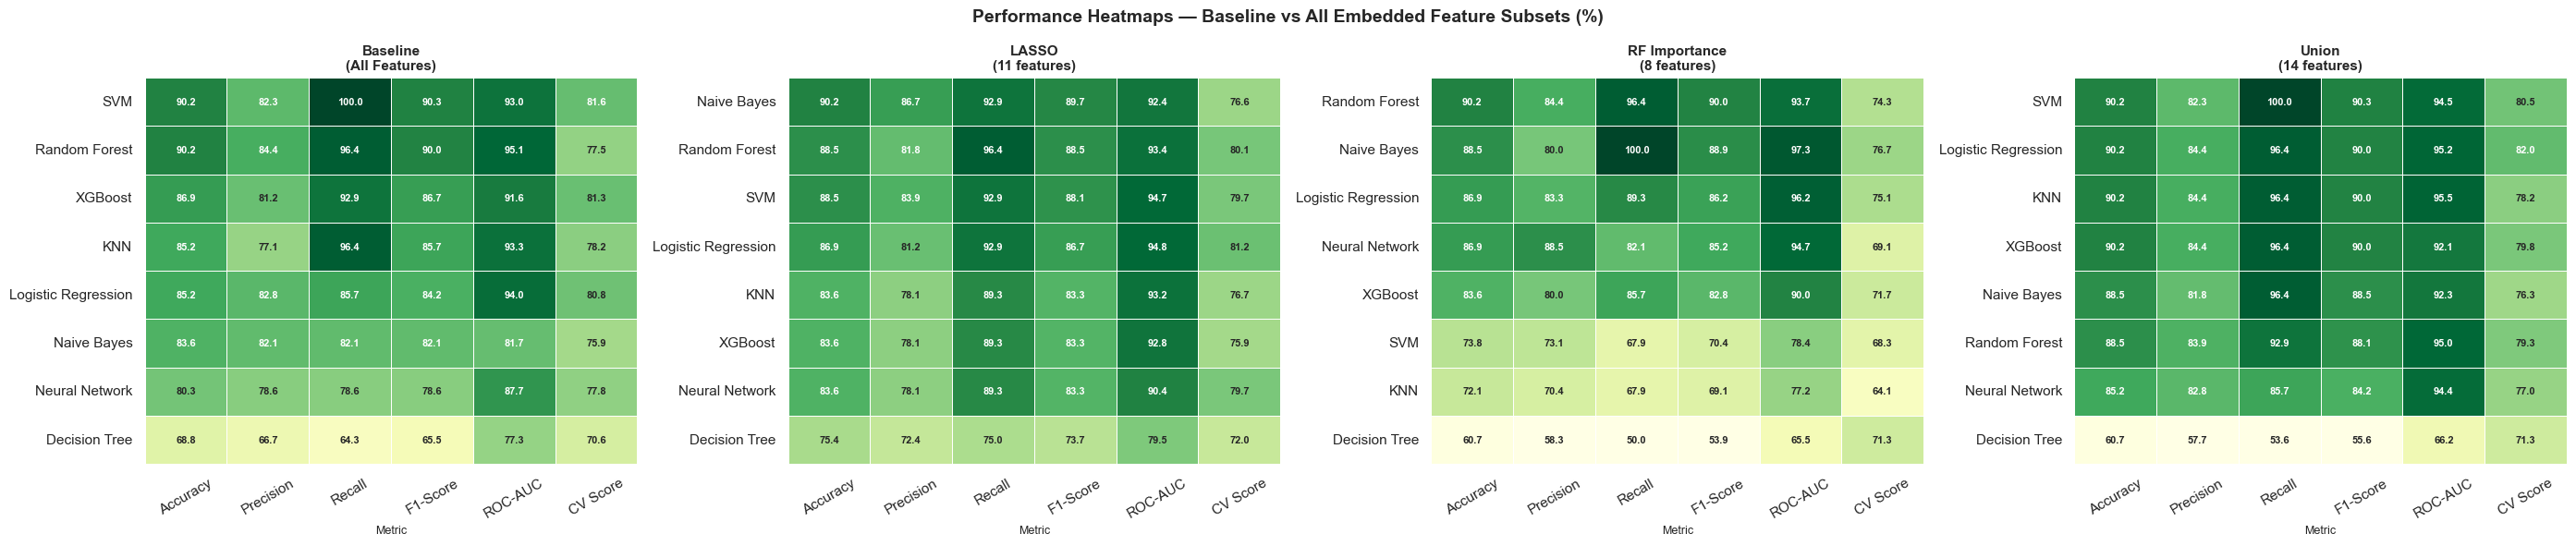

   Heatmap comparison saved!


In [14]:
# ============================================================
# CELL 14 — Heatmaps for All Subsets
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

baseline_df_plot = pd.DataFrame(baseline_results).T.sort_values('F1-Score', ascending=False)

datasets = [
    (baseline_df_plot, 'Baseline\n(All Features)'),
    (df_lasso,         f'LASSO\n({len(lasso_selected_features)} features)'),
    (df_rf,            f'RF Importance\n({len(rf_selected_features)} features)'),
    (df_union,         f'Union\n({len(final_selected_features)} features)'),
]

for ax, (data, title) in zip(axes, datasets):
    sns.heatmap(
        data,
        annot=True, fmt='.1f', cmap='YlGn',
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 8, 'weight': 'bold'},
        vmin=60, vmax=100, ax=ax, cbar=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Performance Heatmaps — Baseline vs All Embedded Feature Subsets (%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('embedded_heatmaps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Heatmap comparison saved!')

---
## Cell 15 — ROC Curves: Best Embedded Subset vs Baseline

Best overall subset: Union (avg F1 = 84.59%)
Avg F1 scores: LASSO=84.58%  RF=78.30%  Union=84.59%


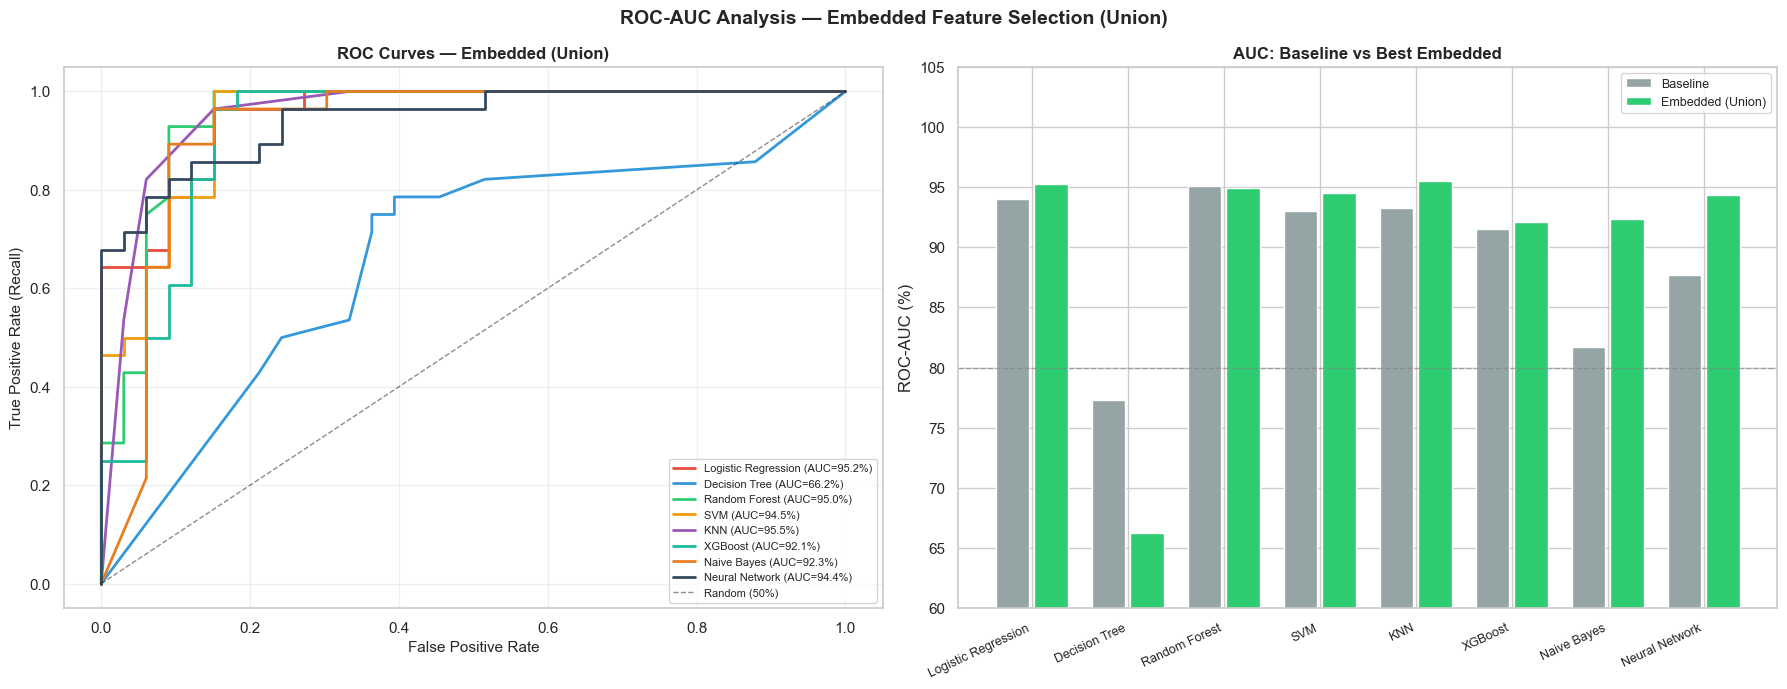

   ROC curves saved!


In [15]:
# ============================================================
# CELL 15 — ROC Curves: Best Subset vs Baseline
# ============================================================

# Determine which subset was best overall (highest average F1)
avg_f1 = {
    'LASSO': np.mean([results_lasso[n]['F1-Score'] for n in model_names]),
    'RF':    np.mean([results_rf[n]['F1-Score']    for n in model_names]),
    'Union': np.mean([results_union[n]['F1-Score'] for n in model_names]),
}
best_subset_name = max(avg_f1, key=avg_f1.get)
best_results     = {'LASSO': results_lasso, 'RF': results_rf, 'Union': results_union}[best_subset_name]
best_X_train     = {'LASSO': X_train_lasso, 'RF': X_train_rf, 'Union': X_train_union}[best_subset_name]
best_X_test      = {'LASSO': X_test_lasso,  'RF': X_test_rf,  'Union': X_test_union}[best_subset_name]

print(f'Best overall subset: {best_subset_name} (avg F1 = {avg_f1[best_subset_name]:.2f}%)')
print(f'Avg F1 scores: LASSO={avg_f1["LASSO"]:.2f}%  RF={avg_f1["RF"]:.2f}%  Union={avg_f1["Union"]:.2f}%')

# Retrain models on best subset to get probabilities for ROC
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, name in enumerate(model_names):
    model = get_models()[name]
    model.fit(best_X_train, y_train)
    y_prob = model.predict_proba(best_X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = best_results[name]['ROC-AUC']
    axes[0].plot(fpr, tpr, color=colors[i], linewidth=2,
                label=f'{name} (AUC={auc_val:.1f}%)')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (50%)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title(f'ROC Curves — Embedded ({best_subset_name})', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# AUC comparison: baseline vs best embedded
baseline_aucs  = [baseline_results[n]['ROC-AUC'] for n in model_names]
embedded_aucs  = [best_results[n]['ROC-AUC']     for n in model_names]

x = np.arange(len(model_names))
axes[1].bar(x - 0.2, baseline_aucs, 0.35, label='Baseline', color='#95a5a6', edgecolor='white')
axes[1].bar(x + 0.2, embedded_aucs, 0.35, label=f'Embedded ({best_subset_name})', color='#2ecc71', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('ROC-AUC (%)')
axes[1].set_title('AUC: Baseline vs Best Embedded', fontsize=12, fontweight='bold')
axes[1].set_ylim(60, 105)
axes[1].axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].legend(fontsize=9)

plt.suptitle(f'ROC-AUC Analysis — Embedded Feature Selection ({best_subset_name})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('embedded_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('   ROC curves saved!')

---
## Cell 16 — Save All Results

In [16]:
# ============================================================
# CELL 16 — Save All Outputs
# ============================================================

SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save selected feature lists
joblib.dump(lasso_selected_features,  f'{SAVE_DIR}/embedded_lasso_features.pkl')
joblib.dump(rf_selected_features,     f'{SAVE_DIR}/embedded_rf_features.pkl')
joblib.dump(final_selected_features,  f'{SAVE_DIR}/embedded_union_features.pkl')
print('  ✅ embedded_lasso_features.pkl  → LASSO selected feature names')
print('  ✅ embedded_rf_features.pkl     → RF selected feature names')
print('  ✅ embedded_union_features.pkl  → Union selected feature names')

# Save results dictionaries
joblib.dump(results_lasso,  f'{SAVE_DIR}/embedded_results_lasso.pkl')
joblib.dump(results_rf,     f'{SAVE_DIR}/embedded_results_rf.pkl')
joblib.dump(results_union,  f'{SAVE_DIR}/embedded_results_union.pkl')
print('  ✅ embedded_results_lasso.pkl   → LASSO model results')
print('  ✅ embedded_results_rf.pkl      → RF model results')
print('  ✅ embedded_results_union.pkl   → Union model results')

# Save comparison DataFrame as CSV
comparison_df.to_csv(f'{SAVE_DIR}/embedded_comparison.csv', index=False)
print('  ✅ embedded_comparison.csv      → Baseline vs Embedded comparison table')

# Save feature importance scores
lasso_coefs.to_csv(f'{SAVE_DIR}/lasso_coefficients.csv', header=['coefficient'])
rf_importances.to_csv(f'{SAVE_DIR}/rf_importances.csv', header=['importance'])
print('  ✅ lasso_coefficients.csv       → LASSO feature coefficients')
print('  ✅ rf_importances.csv           → RF feature importances')

print(f'\n  ✅ All outputs saved to: {SAVE_DIR}/')

  ✅ embedded_lasso_features.pkl  → LASSO selected feature names
  ✅ embedded_rf_features.pkl     → RF selected feature names
  ✅ embedded_union_features.pkl  → Union selected feature names
  ✅ embedded_results_lasso.pkl   → LASSO model results
  ✅ embedded_results_rf.pkl      → RF model results
  ✅ embedded_results_union.pkl   → Union model results
  ✅ embedded_comparison.csv      → Baseline vs Embedded comparison table
  ✅ lasso_coefficients.csv       → LASSO feature coefficients
  ✅ rf_importances.csv           → RF feature importances

  ✅ All outputs saved to: saved_data/


---
## Cell 17 — Final Summary Report

In [17]:
# ============================================================
# CELL 17 — Final Summary Report
# ============================================================

print('=' * 65)
print('       EMBEDDED FEATURE SELECTION — SUMMARY REPORT')
print('    Heart Disease Prediction — UCI Cleveland Dataset')
print('=' * 65)

print(f'\n  INPUT:')
print(f'    Total features (after encoding) : {len(feature_names)}')
print(f'    Training samples                : {X_train_scaled.shape[0]}')
print(f'    Test samples                    : {X_test_scaled.shape[0]}')

print(f'\n  METHOD 1 — LASSO (L1 Regularization):')
print(f'    Model      : LogisticRegression(penalty="l1", C=0.1)')
print(f'    How it works: Shrinks weak feature weights to exactly 0 during training')
print(f'    Features selected: {len(lasso_selected_features)} / {len(feature_names)}')
print(f'    → {lasso_selected_features}')

print(f'\n  METHOD 2 — Random Forest Feature Importance:')
print(f'    Model      : RandomForestClassifier(n_estimators=200)')
print(f'    How it works: Measures impurity reduction per feature across 200 trees')
print(f'    Threshold  : Mean importance ({mean_importance:.4f})')
print(f'    Features selected: {len(rf_selected_features)} / {len(feature_names)}')
print(f'    → {rf_selected_features}')

print(f'\n  COMBINED SELECTION (Union):')
print(f'    Features selected by BOTH  : {sorted(both_selected)}')
print(f'    Final union feature count  : {len(final_selected_features)}')
print(f'    → {final_selected_features}')

print(f'\n  BEST SUBSET OVERALL: {best_subset_name} (avg F1 = {avg_f1[best_subset_name]:.2f}%)')
print(f'    LASSO avg F1 : {avg_f1["LASSO"]:.2f}%')
print(f'    RF    avg F1 : {avg_f1["RF"]:.2f}%')
print(f'    Union avg F1 : {avg_f1["Union"]:.2f}%')

print(f'\n  COMPARISON vs BASELINE:')
print(f'    Models improved : {improved}')
print(f'    Models declined : {declined}')
print(f'    Models unchanged: {same}')

print(f'\n  PLOTS SAVED:')
print(f'    → embedded_lasso_features.png')
print(f'    → embedded_rf_importance.png')
print(f'    → embedded_vs_baseline_barchart.png')
print(f'    → embedded_heatmaps_comparison.png')
print(f'    → embedded_roc_curves.png')

print()
print('=' * 65)
print('  ✅ Embedded Feature Selection Complete!')
print('=' * 65)

       EMBEDDED FEATURE SELECTION — SUMMARY REPORT
    Heart Disease Prediction — UCI Cleveland Dataset

  INPUT:
    Total features (after encoding) : 22
    Training samples                : 262
    Test samples                    : 61

  METHOD 1 — LASSO (L1 Regularization):
    Model      : LogisticRegression(penalty="l1", C=0.1)
    How it works: Shrinks weak feature weights to exactly 0 during training
    Features selected: 11 / 22
    → ['sex', 'thalach', 'exang', 'oldpeak', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7', 'ca_1', 'ca_2', 'ca_3']

  METHOD 2 — Random Forest Feature Importance:
    Model      : RandomForestClassifier(n_estimators=200)
    How it works: Measures impurity reduction per feature across 200 trees
    Threshold  : Mean importance (0.0455)
    Features selected: 8 / 22
    → ['age', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'cp_4.0', 'thal_7']

  COMBINED SELECTION (Union):
    Features selected by BOTH  : ['cp_4.0', 'exang', 'oldpeak', 'thal_7', 't